In [87]:
#librairies natives
import sqlite3

#librairies tierces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#imports spécifiques
from sklearn.preprocessing import StandardScaler, RobustScaler

# Récupérer Data

In [88]:
with sqlite3.connect("olist.db") as con:
    data = pd.read_sql_query("Select * from rfm_table", con)

data.shape

(110840, 5)

In [89]:
data.head()

,order_id,customer_unique_id,order_purchase_timestamp,review_score,price
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2.458029e+06,4.0,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2.458324e+06,4.0,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2.458339e+06,5.0,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2.458076e+06,5.0,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2.458163e+06,5.0,19.90


In [90]:
data.duplicated().sum()

np.int64(11577)

In [91]:
data = data.drop_duplicates()

In [92]:
agg = data.groupby("customer_unique_id").agg(
     frequency=pd.NamedAgg(column="order_id", aggfunc="count"),
     recency=pd.NamedAgg(column="order_purchase_timestamp", aggfunc="max"),
     monetary=pd.NamedAgg(column="price", aggfunc="sum"),
     contentment=pd.NamedAgg(column="review_score", aggfunc="mean")
)

agg.head()

,frequency,recency,monetary,contentment
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,2.458249e+06,129.90,5.0
0000b849f77a49e4a4ce2b2a4ca5be3f,1,2.458246e+06,18.90,4.0
0000f46a3911fa3c0805444483337064,1,2.457823e+06,69.00,3.0
0000f6ccb0745a6a4b88665a16c9f078,1,2.458039e+06,25.99,4.0
0004aac84e0df4da2b147fca70cf8255,1,2.458072e+06,180.00,5.0


# Nettoyer Data

In [95]:
agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93329 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   frequency    93329 non-null  int64  
 1   recency      93329 non-null  float64
 2   monetary     93329 non-null  float64
 3   contentment  92726 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 3.6+ MB


Calculer la récence: la différence entre la date du dernier achat disponible et l'achat du client

In [96]:
agg["recency"] = round(data["order_purchase_timestamp"].max() - agg["recency"])

remplacer les scores de satisfaction manquants par le score de satisfaction médian

In [97]:
agg.loc[agg["contentment"].isna(), "contentment"] = agg["contentment"].median()

In [98]:
agg["monetary"] = np.log(agg["monetary"])

In [99]:
agg.head()

,frequency,recency,monetary,contentment
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,111.0,4.866765,5.0
0000b849f77a49e4a4ce2b2a4ca5be3f,1,114.0,2.939162,4.0
0000f46a3911fa3c0805444483337064,1,537.0,4.234107,3.0
0000f6ccb0745a6a4b88665a16c9f078,1,321.0,3.257712,4.0
0004aac84e0df4da2b147fca70cf8255,1,288.0,5.192957,5.0


In [100]:
# standardisation par la moyenne et l'écart type
scaler = StandardScaler() 
agg[["monetary", "recency", "contentment"]] = scaler.fit_transform(agg[["monetary", "recency", "contentment"]])

# standardisation par la médiane et l'ecart interquartile
r_scaler = RobustScaler() 
agg["frequency"] = r_scaler.fit_transform(agg[["frequency"]])

In [101]:
agg.describe()

,frequency,recency,monetary,contentment
count,93329.000000,9.332900e+04,9.332900e+04,9.332900e+04
mean,0.061406,5.649077e-17,-2.311782e-16,-7.951152e-17
std,0.282593,1.000005e+00,1.000005e+00,1.000005e+00
min,0.000000,-1.556608e+00,-4.907262e+00,-2.472160e+00
25%,0.000000,-8.095184e-01,-6.450678e-01,-1.245265e-01
50%,0.000000,-1.214097e-01,-2.315021e-02,6.580181e-01
75%,0.000000,7.108743e-01,6.401016e-01,6.580181e-01
max,4.000000,3.115978e+00,4.837906e+00,6.580181e-01


# Visualiser Data

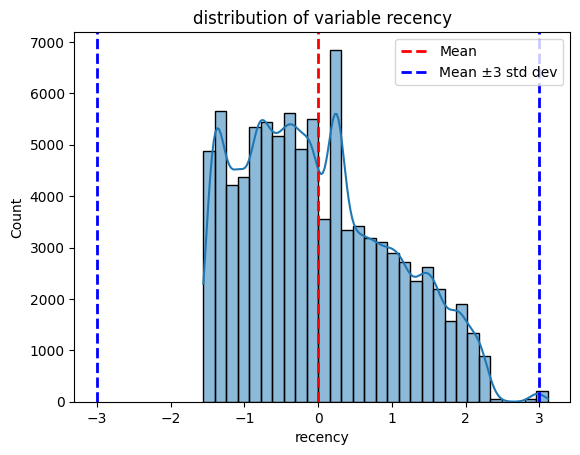

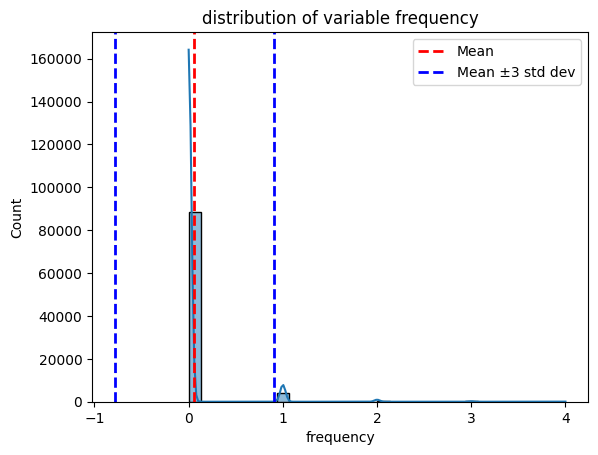

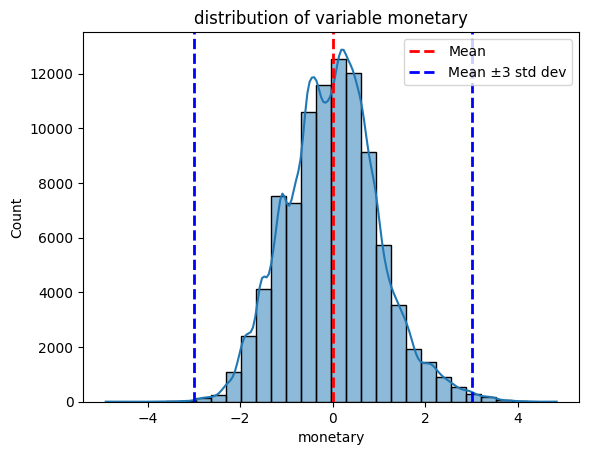

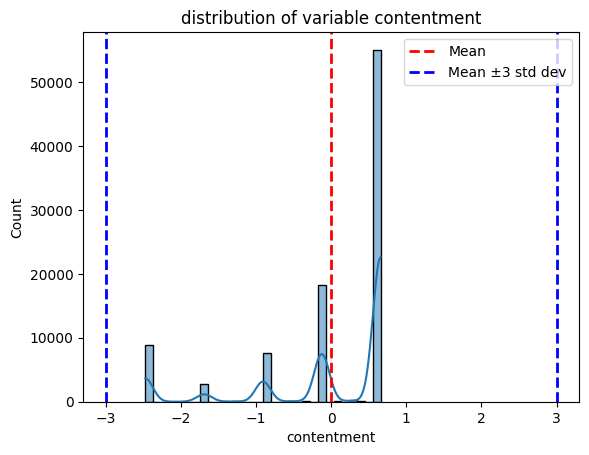

In [102]:
for col in ["recency", "frequency", "monetary", "contentment"]:
    values = agg[col]
        
    mean_val = values.mean()
    std_val = values.std()
    
    sns.histplot(values, kde=True, bins=30)
    
    # adding vertical line a mean+-3 std_dev
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label='Mean')
    plt.axvline(mean_val - 3*std_val, color='blue', linestyle='dashed', linewidth=2, label='Mean ±3 std dev')
    plt.axvline(mean_val + 3*std_val, color='blue', linestyle='dashed', linewidth=2)

    plt.title(f"distribution of variable {col}") 
    plt.legend()
    plt.show()

<Axes: >

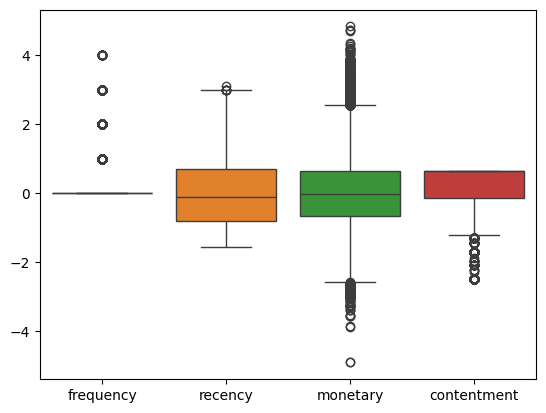

In [103]:
sns.boxplot(data=agg)

<Axes: >

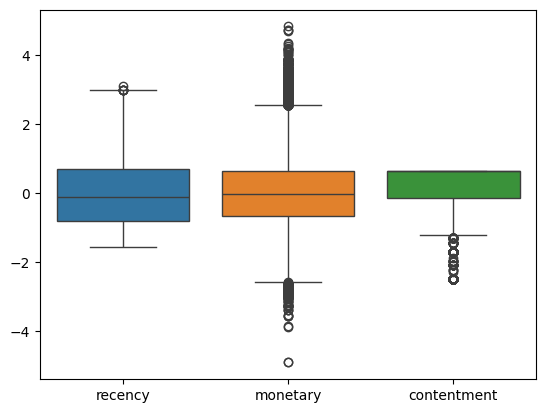

In [104]:
sns.boxplot(data=agg[["recency", "monetary", "contentment"]])

In [105]:
def plot_3D(data, columns):
    """
    Plots a 3D scatter plot of the data.

    Parameters:
    ----------
    data : pandas.DataFrame
        The data to plot, must include a 'cluster' column for coloring.
    columns : list of str
        A list containing the names of the variables to plot on the x, y, and z axes.

    Returns:
    --------
    None
    """
    
    fig = px.scatter_3d(
        data,
        x=columns[0],
        y=columns[1],
        z=columns[2],
        title='3D Scatter Plot',
        opacity=0.8
    )

    # Personnalisation
    fig.update_traces(marker=dict(size=5))  # Taille des points
    fig.update_layout(scene=dict(
        xaxis_title=columns[0],
        yaxis_title=columns[1],
        zaxis_title=columns[2]
    ))

    fig.show()

In [106]:
columns = agg.columns.to_list()
plot_3D(agg, columns)

In [107]:
plot_3D(agg, ("recency", "monetary", "contentment"))

In [108]:
agg.to_csv("data_cleaned.csv")